Homework 2

Student name: Omar Mina-Blanco

Student ID: 800863173

In [1]:
import urllib.request
from dataclasses import dataclass
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import random

#similar to the examples
def set_seed(seed=26): #random seed 26
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(26)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using gpu", device)

using gpu cuda


In [2]:
problem1_sequence = """
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.
At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.
One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.
Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.
Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.
In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.
""".strip()

print("text length:", len(problem1_sequence))
print("unique characters:", len(set(problem1_sequence)))

text length: 2386
unique characters: 45


In [4]:
def build_vocab(text): #Builds character-to-index and index-to-character mappings
    #creates a vocabulary from text
    chars = sorted(list(set(text)))
    char_to_idx = {ch: i for i, ch in enumerate(chars)}
    idx_to_char = {i: ch for ch, i in char_to_idx.items()}
    return chars, char_to_idx, idx_to_char


class CharDataset(Dataset): #creates sequence pairs from text
    """
    Character-level sequence dataset.

    x = encoded[i : i + seq_len]
    y = encoded[i + 1 : i + seq_len + 1]
    """
    def __init__(self, text, seq_len, char_to_idx=None, idx_to_char=None):
        if len(text) <= seq_len:
            raise ValueError(f"Text length must be greater than seq_len. Got len(text)={len(text)}, seq_len={seq_len}")

        self.text = text
        self.seq_len = seq_len

        if char_to_idx is None or idx_to_char is None:
            self.chars, self.char_to_idx, self.idx_to_char = build_vocab(text)
        else:
            self.char_to_idx = char_to_idx
            self.idx_to_char = idx_to_char
            self.chars = [idx_to_char[i] for i in range(len(idx_to_char))]

        self.vocab_size = len(self.chars)
        self.encoded = torch.tensor([self.char_to_idx[ch] for ch in text], dtype=torch.long)

    def __len__(self):
        return len(self.encoded) - self.seq_len

    def __getitem__(self, idx):
        x = self.encoded[idx : idx + self.seq_len]
        y = self.encoded[idx + 1 : idx + self.seq_len + 1]
        return x, y


def make_char_datasets(text, seq_len, val_fraction=0.2):

    #Make train and validation datasets using a split. Both datasets share the same vocabulary
    chars, char_to_idx, idx_to_char = build_vocab(text)
    split_idx = int((1.0 - val_fraction) * len(text))

    # Add seq_len extra characters to validation text so the first validation windows are valid
    train_text = text[:split_idx]
    val_text = text[max(0, split_idx - seq_len):]

    train_dataset = CharDataset(train_text, seq_len, char_to_idx, idx_to_char)
    val_dataset = CharDataset(val_text, seq_len, char_to_idx, idx_to_char)
    return train_dataset, val_dataset


def make_loaders(text, seq_len, batch_size, val_fraction=0.2):
    train_dataset, val_dataset = make_char_datasets(text, seq_len, val_fraction=val_fraction)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        pin_memory=torch.cuda.is_available(),
        num_workers=2 if torch.cuda.is_available() else 0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        pin_memory=torch.cuda.is_available(),
        num_workers=2 if torch.cuda.is_available() else 0,
    )
    return train_dataset, val_dataset, train_loader, val_loader


demo_dataset = CharDataset(problem1_sequence, seq_len=10)
print("Vocabulary size:", demo_dataset.vocab_size)
print("First input index:", demo_dataset[0][0])
print("First target index:", demo_dataset[0][1])
print("First input text:", ''.join(demo_dataset.idx_to_char[i.item()] for i in demo_dataset[0][0]))
print("First target text:", ''.join(demo_dataset.idx_to_char[i.item()] for i in demo_dataset[0][1]))


Vocabulary size: 45
First input index: tensor([13, 23, 42, 38,  1, 21, 26, 19, 36, 19])
First target index: tensor([23, 42, 38,  1, 21, 26, 19, 36, 19, 21])
First input text: Next chara
First target text: ext charac


In [5]:
class CharRNNModel(nn.Module): #can run different neural networks, 64 embedding layes for characters, 128 for hidden layers for A100 gpu
    def __init__(self, vocab_size, model_type="RNN", embedding_dim=64,
                 hidden_size=128, num_layers=1, fc_size=0, dropout=0.0):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
#rnn.RNN, rnn.LSTM and rnn.GRU for learning sequence.
        rnn_classes = {
            "RNN": nn.RNN,
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }
        rnn_cls = rnn_classes[self.model_type]

        self.rnn = rnn_cls(
            input_size= embedding_dim,
            hidden_size= hidden_size,
            num_layers= num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        if fc_size > 0:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, fc_size),
                nn.ReLU(),
                nn.Linear(fc_size, vocab_size),
            )
        else:
            self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def estimate_recurrent_ops(model_type, seq_len, embedding_dim, hidden_size, num_layers): #get the total recurrent operations for a given sequence length

    gates = {"RNN": 1, "GRU": 3, "LSTM": 4}[model_type.upper()]
    first_layer = gates * (embedding_dim * hidden_size + hidden_size * hidden_size)
    extra_layers = max(0, num_layers - 1) * gates * (hidden_size * hidden_size + hidden_size * hidden_size)
    return seq_len * (first_layer + extra_layers)


def evaluate(model, loader, criterion, device): #performance of model
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    start = time.perf_counter()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits, _ = model(x)
            loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            total_loss += loss.item()
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.numel()

    inference_time = time.perf_counter() - start
    avg_loss = total_loss / max(1, len(loader))
    accuracy = correct / max(1, total)
    perplexity = math.exp(avg_loss) if avg_loss < 20 else float("inf")
    return avg_loss, accuracy, perplexity, inference_time


def generate_text(model, dataset, seed="To be", length=200, temperature=0.8): #0.8 probabilty , 200 characters to generate
    model.eval()

    valid_seed = "".join(ch for ch in seed if ch in dataset.char_to_idx)
    if len(valid_seed) == 0:
        valid_seed = dataset.idx_to_char[0]

    generated = valid_seed
    x = torch.tensor([[dataset.char_to_idx[ch] for ch in valid_seed]], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(length):
            logits, _ = model(x)
            next_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(next_logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1).item()
            next_char = dataset.idx_to_char[next_idx]
            generated += next_char

            context = generated[-dataset.seq_len:]
            x = torch.tensor([[dataset.char_to_idx[ch] for ch in context]], dtype=torch.long).to(device)

    return generated

In [9]:
@dataclass
class ExperimentConfig:
    dataset_name: str
    model_type: str
    seq_len: int
    epochs: int
    batch_size: int = 128 #batch size for training
    lr: float = 0.002
    embedding_dim: int = 64
    hidden_size: int = 128
    num_layers: int = 1
    fc_size: int = 0
    dropout: float = 0.0
    val_fraction: float = 0.2
    use_amp: bool = True   #faster training for pytorch on A1000


def train_one_experiment(text, cfg, seed_text="Next character"):
    train_dataset, val_dataset, train_loader, val_loader = make_loaders(
        text=text,
        seq_len=cfg.seq_len,
        batch_size=cfg.batch_size,
        val_fraction=cfg.val_fraction,
    )

    model = CharRNNModel(
        vocab_size=train_dataset.vocab_size,
        model_type=cfg.model_type,
        embedding_dim=cfg.embedding_dim,
        hidden_size=cfg.hidden_size,
        num_layers=cfg.num_layers,
        fc_size=cfg.fc_size,
        dropout=cfg.dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and torch.cuda.is_available()))

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []
    start = time.perf_counter()

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        total_loss = 0.0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(cfg.use_amp and torch.cuda.is_available())):
                logits, _ = model(x)
                loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        train_loss = total_loss / max(1, len(train_loader))
        val_loss, val_acc, val_ppl, _ = evaluate(model, val_loader, criterion, device)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

        if epoch == 1 or epoch % max(1, cfg.epochs // 5) == 0 or epoch == cfg.epochs:
            print(
                f"{cfg.dataset_name} | {cfg.model_type} | seq={cfg.seq_len} | "
                f"epoch {epoch:3d}/{cfg.epochs} | train loss={train_loss:.4f} | "
                f"val loss={val_loss:.4f} | val acc={val_acc:.4f}"
            )

    train_time = time.perf_counter() - start
    val_loss, val_acc, val_ppl, inference_time = evaluate(model, val_loader, criterion, device)

    params = count_parameters(model)
    result = {
        "dataset": cfg.dataset_name,
        "model": cfg.model_type,
        "seq_len": cfg.seq_len,
        "epochs": cfg.epochs,
        "batch_size": cfg.batch_size,
        "embedding_dim": cfg.embedding_dim,
        "hidden_size": cfg.hidden_size,
        "num_layers": cfg.num_layers,
        "fully connected hidden layer": cfg.fc_size,
        "dropout": cfg.dropout,
        "train_loss": epoch_train_losses[-1],
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "validation perplexity": val_ppl,
        "train_time": train_time,
        "inference_time": inference_time,
        "params": params,
        "model_size": params * 4 / (1024 ** 2), #for model size in MB
        "recurrent_ops_est": estimate_recurrent_ops(
            cfg.model_type, cfg.seq_len, cfg.embedding_dim, cfg.hidden_size, cfg.num_layers
        ),
        "sample_output": generate_text(model, train_dataset, seed=seed_text, length=200),
        "history": {
            "train_loss": epoch_train_losses,
            "val_loss": epoch_val_losses,
            "val_accuracy": epoch_val_accs,
        },
    }

    return result, model, train_dataset


In [12]:
import time
import math
problem1_results = [] #empty list
problem1_models = {} #empty dictionary

for model_type in ["RNN", "LSTM", "GRU"]:
    for seq_len in [10, 20, 30]:
        cfg = ExperimentConfig(
            dataset_name="Problem 1 Text",
            model_type=model_type,
            seq_len=seq_len,
            epochs=80, #more epochs were used for the dataset
            batch_size=128,
            lr=0.002, #0.001 was slow
            embedding_dim=64,
            hidden_size=128,
            num_layers=1,
            fc_size=0,
            dropout=0.0,
        )
        result, model, dataset = train_one_experiment(problem1_sequence, cfg, seed_text="the next character")
        problem1_results.append(result)
        problem1_models[(model_type, seq_len)] = (model, dataset)

problem1_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["history", "sample_output"]} for r in problem1_results])
problem1_df

/tmp/ipykernel_3702/38111280.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and torch.cuda.is_available()))
/tmp/ipykernel_3702/38111280.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and torch.cuda.is_available())):


Problem 1 Text | RNN | seq=10 | epoch   1/80 | train loss=3.1436 | val loss=2.8314 | val acc=0.2270
Problem 1 Text | RNN | seq=10 | epoch  16/80 | train loss=0.9077 | val loss=2.1620 | val acc=0.4630
Problem 1 Text | RNN | seq=10 | epoch  32/80 | train loss=0.5970 | val loss=2.4904 | val acc=0.4701
Problem 1 Text | RNN | seq=10 | epoch  48/80 | train loss=0.5306 | val loss=2.6764 | val acc=0.4772
Problem 1 Text | RNN | seq=10 | epoch  64/80 | train loss=0.5098 | val loss=2.8154 | val acc=0.4768
Problem 1 Text | RNN | seq=10 | epoch  80/80 | train loss=0.4929 | val loss=2.9097 | val acc=0.4711
Problem 1 Text | RNN | seq=20 | epoch   1/80 | train loss=3.0863 | val loss=2.7230 | val acc=0.2595
Problem 1 Text | RNN | seq=20 | epoch  16/80 | train loss=0.5596 | val loss=2.3177 | val acc=0.4899
Problem 1 Text | RNN | seq=20 | epoch  32/80 | train loss=0.3263 | val loss=2.7737 | val acc=0.4918
Problem 1 Text | RNN | seq=20 | epoch  48/80 | train loss=0.2853 | val loss=2.9904 | val acc=0.4969


/tmp/ipykernel_3702/38111280.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and torch.cuda.is_available())):


Problem 1 Text | LSTM | seq=20 | epoch  32/80 | train loss=0.3307 | val loss=2.5594 | val acc=0.4802
Problem 1 Text | LSTM | seq=20 | epoch  48/80 | train loss=0.2785 | val loss=2.7932 | val acc=0.4823
Problem 1 Text | LSTM | seq=20 | epoch  64/80 | train loss=0.2593 | val loss=2.9632 | val acc=0.4790
Problem 1 Text | LSTM | seq=20 | epoch  80/80 | train loss=0.2513 | val loss=3.0758 | val acc=0.4803


/tmp/ipykernel_3702/38111280.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and torch.cuda.is_available()))


...

/tmp/ipykernel_3702/38111280.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and torch.cuda.is_available())):


Problem 1 Text | LSTM | seq=30 | epoch  16/80 | train loss=0.5698 | val loss=2.1870 | val acc=0.4739
Problem 1 Text | LSTM | seq=30 | epoch  32/80 | train loss=0.2454 | val loss=2.5176 | val acc=0.4870
Problem 1 Text | LSTM | seq=30 | epoch  48/80 | train loss=0.1980 | val loss=2.7449 | val acc=0.4925
Problem 1 Text | LSTM | seq=30 | epoch  64/80 | train loss=0.1823 | val loss=2.8901 | val acc=0.4910
Problem 1 Text | LSTM | seq=30 | epoch  80/80 | train loss=0.1741 | val loss=3.0272 | val acc=0.4955


/tmp/ipykernel_3702/38111280.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and torch.cuda.is_available()))


Problem 1 Text | GRU | seq=10 | epoch   1/80 | train loss=3.2512 | val loss=2.9373 | val acc=0.2215
Problem 1 Text | GRU | seq=10 | epoch  16/80 | train loss=0.7611 | val loss=2.1942 | val acc=0.4900
Problem 1 Text | GRU | seq=10 | epoch  32/80 | train loss=0.5215 | val loss=2.5713 | val acc=0.4849
Problem 1 Text | GRU | seq=10 | epoch  48/80 | train loss=0.4841 | val loss=2.7564 | val acc=0.4860
Problem 1 Text | GRU | seq=10 | epoch  64/80 | train loss=0.4728 | val loss=2.8897 | val acc=0.4918
Problem 1 Text | GRU | seq=10 | epoch  80/80 | train loss=0.4654 | val loss=3.0028 | val acc=0.4885
Problem 1 Text | GRU | seq=20 | epoch   1/80 | train loss=3.2759 | val loss=2.9469 | val acc=0.2077
Problem 1 Text | GRU | seq=20 | epoch  16/80 | train loss=0.4568 | val loss=2.2823 | val acc=0.4994
Problem 1 Text | GRU | seq=20 | epoch  32/80 | train loss=0.2787 | val loss=2.6607 | val acc=0.5075
Problem 1 Text | GRU | seq=20 | epoch  48/80 | train loss=0.2555 | val loss=2.8439 | val acc=0.5063


,dataset,model,seq_len,epochs,batch_size,embedding_dim,hidden_size,num_layers,fully connected hidden layer,dropout,train_loss,val_loss,val_accuracy,validation perplexity,train_time,inference_time,params,model_size,recurrent_ops_est
0,Problem 1 Text,RNN,10,80,128,64,128,1,0,0.0,0.492916,2.909666,0.471130,18.350663,14.902384,0.069107,33517,0.127857,245760
1,Problem 1 Text,RNN,20,80,128,64,128,1,0,0.0,0.261957,3.257714,0.497803,25.990052,15.708730,0.070540,33517,0.127857,491520
2,Problem 1 Text,RNN,30,80,128,64,128,1,0,0.0,0.179242,3.259384,0.475244,26.033486,16.084707,0.074459,33517,0.127857,737280
3,Problem 1 Text,LSTM,10,80,128,64,128,1,0,0.0,0.476045,2.788582,0.476151,16.257943,16.340004,0.074679,108013,0.412037,983040
4,Problem 1 Text,LSTM,20,80,128,64,128,1,0,0.0,0.251344,3.075810,0.480335,21.667426,16.304992,0.076080,108013,0.412037,1966080
5,Problem 1 Text,LSTM,30,80,128,64,128,1,0,0.0,0.174122,3.027241,0.495467,20.640200,16.724085,0.075475,108013,0.412037,2949120
6,Problem 1 Text,GRU,10,80,128,64,128,1,0,0.0,0.465358,3.002826,0.488494,20.142388,16.219200,0.074567,83181,0.317310,737280
7,Problem 1 Text,GRU,20,80,128,64,128,1,0,0.0,0.243505,3.067938,0.509623,21.497532,16.235233,0.073663,83181,0.317310,1474560
8,Problem 1 Text,GRU,30,80,128,64,128,1,0,0.0,0.164701,3.254836,0.498605,25.915362,16.453324,0.074797,83181,0.317310,2211840


In [15]:
problem1_df[[
    "model", "seq_len", "train_loss", "val_loss", "val_accuracy", "validation perplexity",
    "train_time", "inference_time", "params", "model_size", "recurrent_ops_est"
]].sort_values(["seq_len", "model"])

,model,seq_len,train_loss,val_loss,val_accuracy,validation perplexity,train_time,inference_time,params,model_size,recurrent_ops_est
6,GRU,10,0.465358,3.002826,0.488494,20.142388,16.219200,0.074567,83181,0.317310,737280
3,LSTM,10,0.476045,2.788582,0.476151,16.257943,16.340004,0.074679,108013,0.412037,983040
0,RNN,10,0.492916,2.909666,0.471130,18.350663,14.902384,0.069107,33517,0.127857,245760
7,GRU,20,0.243505,3.067938,0.509623,21.497532,16.235233,0.073663,83181,0.317310,1474560
4,LSTM,20,0.251344,3.075810,0.480335,21.667426,16.304992,0.076080,108013,0.412037,1966080
1,RNN,20,0.261957,3.257714,0.497803,25.990052,15.708730,0.070540,33517,0.127857,491520
8,GRU,30,0.164701,3.254836,0.498605,25.915362,16.453324,0.074797,83181,0.317310,2211840
5,LSTM,30,0.174122,3.027241,0.495467,20.640200,16.724085,0.075475,108013,0.412037,2949120
2,RNN,30,0.179242,3.259384,0.475244,26.033486,16.084707,0.074459,33517,0.127857,737280


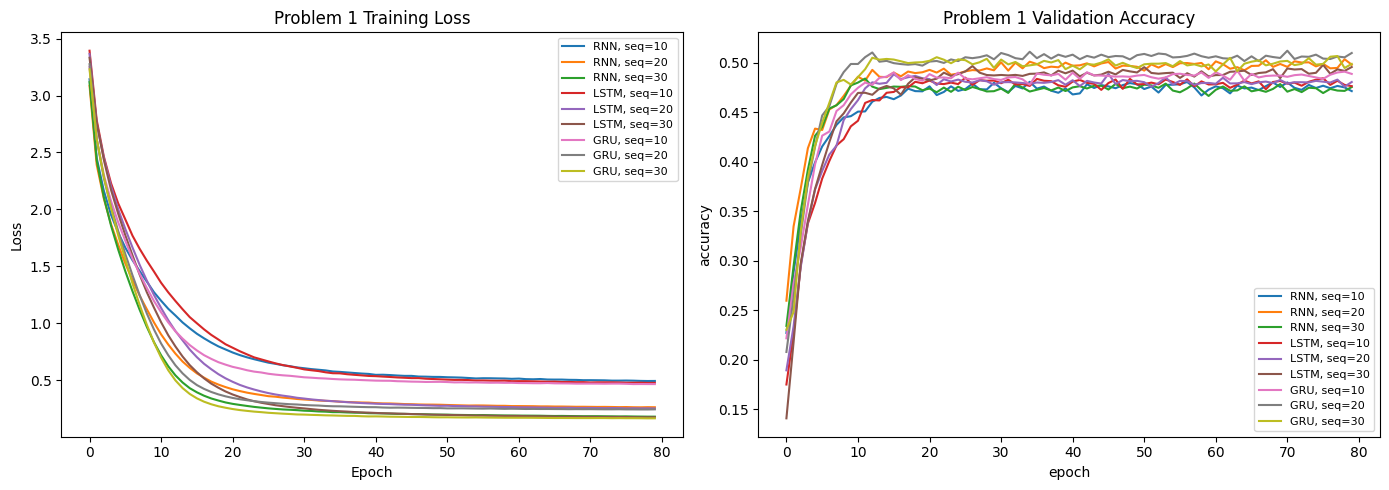

In [17]:
def plot_histories(results, title):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for r in results:
        label = f"{r['model']}, seq={r['seq_len']}"
        plt.plot(r["history"]["train_loss"], label=label)
    plt.title(title + " Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(fontsize=8)

    plt.subplot(1, 2, 2)
    for r in results:
        label = f"{r['model']}, seq={r['seq_len']}"
        plt.plot(r["history"]["val_accuracy"], label=label)
    plt.title(title + " Validation Accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_histories(problem1_results, "Problem 1")

## Problem 2: Tiny Shakespeare text

In [19]:
def load_tiny_shakespeare(path="tiny_shakespeare.txt", use_subset=False, max_chars=300_000):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    path = Path(path)

    if not path.exists():
        urllib.request.urlretrieve(url, path)
    text = path.read_text(encoding="utf-8")
    if use_subset:
        text = text[:max_chars]
    return text


USE_TINY_SUBSET = False   # True or false to change subset
tiny_text = load_tiny_shakespeare(use_subset=USE_TINY_SUBSET)
print("tiny Shakespeare length", len(tiny_text))
print("unique characters:", len(set(tiny_text)))
print(tiny_text[:500]) #first 500 just to check


tiny Shakespeare length 300000
unique characters: 62
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [20]:
problem2_results = []
problem2_models = {}

for model_type in ["LSTM", "GRU"]:
    for seq_len in [20, 30, 50]:
        cfg = ExperimentConfig(
            dataset_name="Tiny Shakespeare",
            model_type=model_type,
            seq_len=seq_len,
            epochs=15, #smaller epochs than problem 1 because of the larger data
            batch_size=256,
            lr=0.002,
            embedding_dim=64,
            hidden_size=128,
            num_layers=1,
            fc_size=0,
            dropout=0.0,
        )
        result, model, dataset = train_one_experiment(tiny_text, cfg, seed_text="To be")
        problem2_results.append(result)
        problem2_models[(model_type, seq_len)] = (model, dataset)

problem2_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["history", "sample_output"]} for r in problem2_results])
problem2_df

/tmp/ipykernel_3702/38111280.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and torch.cuda.is_available()))
/tmp/ipykernel_3702/38111280.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and torch.cuda.is_available())):


Tiny Shakespeare | LSTM | seq=20 | epoch   1/15 | train loss=1.8684 | val loss=1.7666 | val acc=0.4882
Tiny Shakespeare | LSTM | seq=20 | epoch   3/15 | train loss=1.4462 | val loss=1.6869 | val acc=0.5127
Tiny Shakespeare | LSTM | seq=20 | epoch   6/15 | train loss=1.3502 | val loss=1.7192 | val acc=0.5129
Tiny Shakespeare | LSTM | seq=20 | epoch   9/15 | train loss=1.3077 | val loss=1.7643 | val acc=0.5098
Tiny Shakespeare | LSTM | seq=20 | epoch  12/15 | train loss=1.2833 | val loss=1.7885 | val acc=0.5085
Tiny Shakespeare | LSTM | seq=20 | epoch  15/15 | train loss=1.2666 | val loss=1.8195 | val acc=0.5060
Tiny Shakespeare | LSTM | seq=30 | epoch   1/15 | train loss=1.8290 | val loss=1.7298 | val acc=0.5021
Tiny Shakespeare | LSTM | seq=30 | epoch   3/15 | train loss=1.3787 | val loss=1.6897 | val acc=0.5178
Tiny Shakespeare | LSTM | seq=30 | epoch   6/15 | train loss=1.2701 | val loss=1.7356 | val acc=0.5167
Tiny Shakespeare | LSTM | seq=30 | epoch   9/15 | train loss=1.2222 | val

,dataset,model,seq_len,epochs,batch_size,embedding_dim,hidden_size,num_layers,fully connected hidden layer,dropout,train_loss,val_loss,val_accuracy,validation perplexity,train_time,inference_time,params,model_size,recurrent_ops_est
0,Tiny Shakespeare,LSTM,20,15,256,64,128,1,0,0.0,1.266617,1.819538,0.505975,6.169007,70.140774,0.478664,111294,0.424553,1966080
1,Tiny Shakespeare,LSTM,30,15,256,64,128,1,0,0.0,1.178834,1.882417,0.507440,6.569365,69.984428,0.477316,111294,0.424553,2949120
2,Tiny Shakespeare,LSTM,50,15,256,64,128,1,0,0.0,1.088590,1.978978,0.500123,7.235344,71.049851,0.518056,111294,0.424553,4915200
3,Tiny Shakespeare,GRU,20,15,256,64,128,1,0,0.0,1.313177,1.781781,0.508892,5.940428,69.053861,0.507630,86462,0.329826,1474560
4,Tiny Shakespeare,GRU,30,15,256,64,128,1,0,0.0,1.240138,1.831439,0.510139,6.242862,69.189161,0.499982,86462,0.329826,2211840
5,Tiny Shakespeare,GRU,50,15,256,64,128,1,0,0.0,1.172032,1.892163,0.506706,6.633700,71.042900,0.445832,86462,0.329826,3686400


In [22]:
problem2_df[[
    "model", "seq_len", "train_loss", "val_loss", "val_accuracy", "validation perplexity",
    "train_time", "inference_time", "params", "model_size", "recurrent_ops_est"
]].sort_values(["seq_len", "model"])

,model,seq_len,train_loss,val_loss,val_accuracy,validation perplexity,train_time,inference_time,params,model_size,recurrent_ops_est
3,GRU,20,1.313177,1.781781,0.508892,5.940428,69.053861,0.507630,86462,0.329826,1474560
0,LSTM,20,1.266617,1.819538,0.505975,6.169007,70.140774,0.478664,111294,0.424553,1966080
4,GRU,30,1.240138,1.831439,0.510139,6.242862,69.189161,0.499982,86462,0.329826,2211840
1,LSTM,30,1.178834,1.882417,0.507440,6.569365,69.984428,0.477316,111294,0.424553,2949120
5,GRU,50,1.172032,1.892163,0.506706,6.633700,71.042900,0.445832,86462,0.329826,3686400
2,LSTM,50,1.088590,1.978978,0.500123,7.235344,71.049851,0.518056,111294,0.424553,4915200


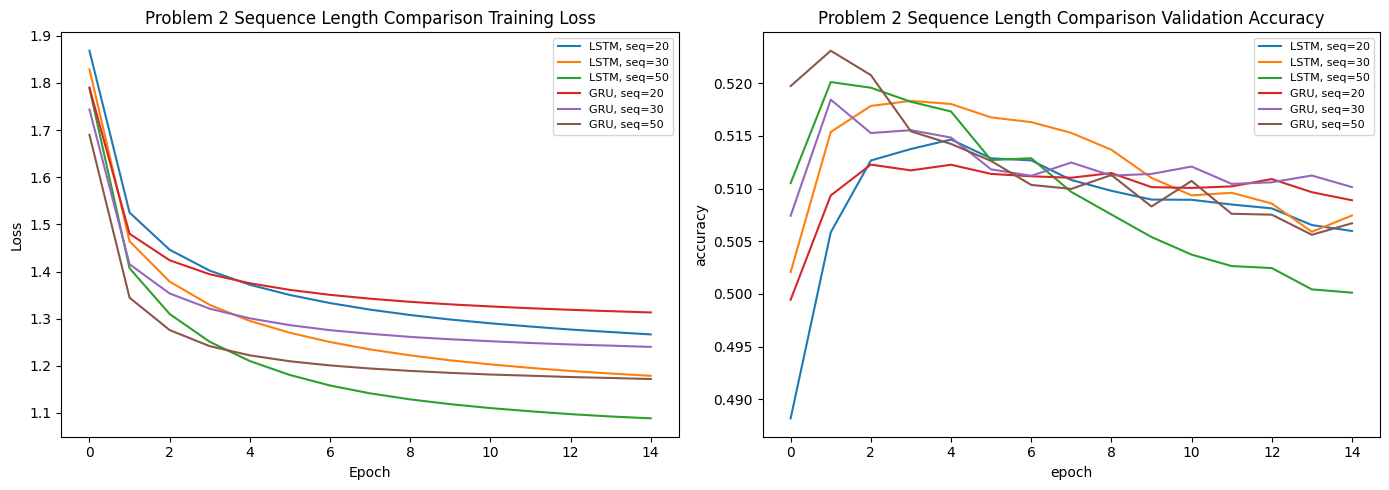

In [24]:
plot_histories(problem2_results, "Problem 2 Sequence Length Comparison")

In [25]:
hyperparameter_results = []

hyperparameter_settings = [
    {"label": "baseline_hidden128_layer1_no_fc", "hidden_size": 128, "num_layers": 1, "fc_size": 0, "dropout": 0.0},
    {"label": "larger_hidden256_layer1_no_fc", "hidden_size": 256, "num_layers": 1, "fc_size": 0, "dropout": 0.0},
    {"label": "deeper_hidden128_layer2_no_fc", "hidden_size": 128, "num_layers": 2, "fc_size": 0, "dropout": 0.2},
    {"label": "extra_hidden128_layer1_fc128", "hidden_size": 128, "num_layers": 1, "fc_size": 128, "dropout": 0.0},
]

for model_type in ["LSTM", "GRU"]:
    for hp in hyperparameter_settings:
        cfg = ExperimentConfig(
            dataset_name=hp["label"],
            model_type=model_type,
            seq_len=30, #balanced for differennt hyper parameter settings
            epochs=15,
            batch_size=256,
            lr=0.002,
            embedding_dim=64,
            hidden_size=hp["hidden_size"],
            num_layers=hp["num_layers"],
            fc_size=hp["fc_size"],
            dropout=hp["dropout"],
        )
        result, model, dataset = train_one_experiment(tiny_text, cfg, seed_text="To be")
        hyperparameter_results.append(result)

hyperparameter_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["history", "sample_output"]} for r in hyperparameter_results])
hyperparameter_df

/tmp/ipykernel_3702/38111280.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and torch.cuda.is_available()))
/tmp/ipykernel_3702/38111280.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and torch.cuda.is_available())):


baseline_hidden128_layer1_no_fc | LSTM | seq=30 | epoch   1/15 | train loss=1.8443 | val loss=1.7341 | val acc=0.4979
baseline_hidden128_layer1_no_fc | LSTM | seq=30 | epoch   3/15 | train loss=1.3975 | val loss=1.6730 | val acc=0.5207
baseline_hidden128_layer1_no_fc | LSTM | seq=30 | epoch   6/15 | train loss=1.2824 | val loss=1.7242 | val acc=0.5188
baseline_hidden128_layer1_no_fc | LSTM | seq=30 | epoch   9/15 | train loss=1.2323 | val loss=1.7806 | val acc=0.5113
baseline_hidden128_layer1_no_fc | LSTM | seq=30 | epoch  12/15 | train loss=1.2040 | val loss=1.8271 | val acc=0.5087
baseline_hidden128_layer1_no_fc | LSTM | seq=30 | epoch  15/15 | train loss=1.1862 | val loss=1.8548 | val acc=0.5069
larger_hidden256_layer1_no_fc | LSTM | seq=30 | epoch   1/15 | train loss=1.6594 | val loss=1.6595 | val acc=0.5174
larger_hidden256_layer1_no_fc | LSTM | seq=30 | epoch   3/15 | train loss=1.1162 | val loss=1.8147 | val acc=0.5147
larger_hidden256_layer1_no_fc | LSTM | seq=30 | epoch   6/15

,dataset,model,seq_len,epochs,batch_size,embedding_dim,hidden_size,num_layers,fully connected hidden layer,dropout,train_loss,val_loss,val_accuracy,validation perplexity,train_time,inference_time,params,model_size,recurrent_ops_est
0,baseline_hidden128_layer1_no_fc,LSTM,30,15,256,64,128,1,0,0.0,1.186239,1.854769,0.506948,6.390224,71.631688,0.481849,111294,0.424553,2949120
1,larger_hidden256_layer1_no_fc,LSTM,30,15,256,64,256,1,0,0.0,0.755896,2.496305,0.487659,12.137559,76.083659,0.462233,349630,1.333733,9830400
2,deeper_hidden128_layer2_no_fc,LSTM,30,15,256,64,128,2,0,0.2,1.190520,1.746760,0.524161,5.735986,78.778226,0.469405,243390,0.928459,6881280
3,extra_hidden128_layer1_fc128,LSTM,30,15,256,64,128,1,128,0.0,1.081887,2.164374,0.500527,8.709150,73.251044,0.456684,127806,0.487541,2949120
4,baseline_hidden128_layer1_no_fc,GRU,30,15,256,64,128,1,0,0.0,1.239162,1.799790,0.515032,6.048376,69.845303,0.465912,86462,0.329826,2211840
5,larger_hidden256_layer1_no_fc,GRU,30,15,256,64,256,1,0,0.0,0.858385,2.298592,0.495426,9.960150,77.385413,0.472536,267198,1.019279,7372800
6,deeper_hidden128_layer2_no_fc,GRU,30,15,256,64,128,2,0,0.2,1.259749,1.661288,0.530448,5.266091,75.088447,0.452180,185534,0.707756,5160960
7,extra_hidden128_layer1_fc128,GRU,30,15,256,64,128,1,128,0.0,1.132529,2.062895,0.505666,7.868716,73.061530,0.511791,102974,0.392815,2211840


In [27]:
hyperparameter_df[[
    "dataset", "model", "seq_len", "hidden_size", "num_layers", "fully connected hidden layer", "dropout",
    "train_loss", "val_loss", "val_accuracy", "validation perplexity",
    "train_time", "inference_time", "params", "model_size", "recurrent_ops_est"
]].sort_values(["model", "dataset"])

,dataset,model,seq_len,hidden_size,num_layers,fully connected hidden layer,dropout,train_loss,val_loss,val_accuracy,validation perplexity,train_time,inference_time,params,model_size,recurrent_ops_est
4,baseline_hidden128_layer1_no_fc,GRU,30,128,1,0,0.0,1.239162,1.799790,0.515032,6.048376,69.845303,0.465912,86462,0.329826,2211840
6,deeper_hidden128_layer2_no_fc,GRU,30,128,2,0,0.2,1.259749,1.661288,0.530448,5.266091,75.088447,0.452180,185534,0.707756,5160960
7,extra_hidden128_layer1_fc128,GRU,30,128,1,128,0.0,1.132529,2.062895,0.505666,7.868716,73.061530,0.511791,102974,0.392815,2211840
5,larger_hidden256_layer1_no_fc,GRU,30,256,1,0,0.0,0.858385,2.298592,0.495426,9.960150,77.385413,0.472536,267198,1.019279,7372800
0,baseline_hidden128_layer1_no_fc,LSTM,30,128,1,0,0.0,1.186239,1.854769,0.506948,6.390224,71.631688,0.481849,111294,0.424553,2949120
2,deeper_hidden128_layer2_no_fc,LSTM,30,128,2,0,0.2,1.190520,1.746760,0.524161,5.735986,78.778226,0.469405,243390,0.928459,6881280
3,extra_hidden128_layer1_fc128,LSTM,30,128,1,128,0.0,1.081887,2.164374,0.500527,8.709150,73.251044,0.456684,127806,0.487541,2949120
1,larger_hidden256_layer1_no_fc,LSTM,30,256,1,0,0.0,0.755896,2.496305,0.487659,12.137559,76.083659,0.462233,349630,1.333733,9830400


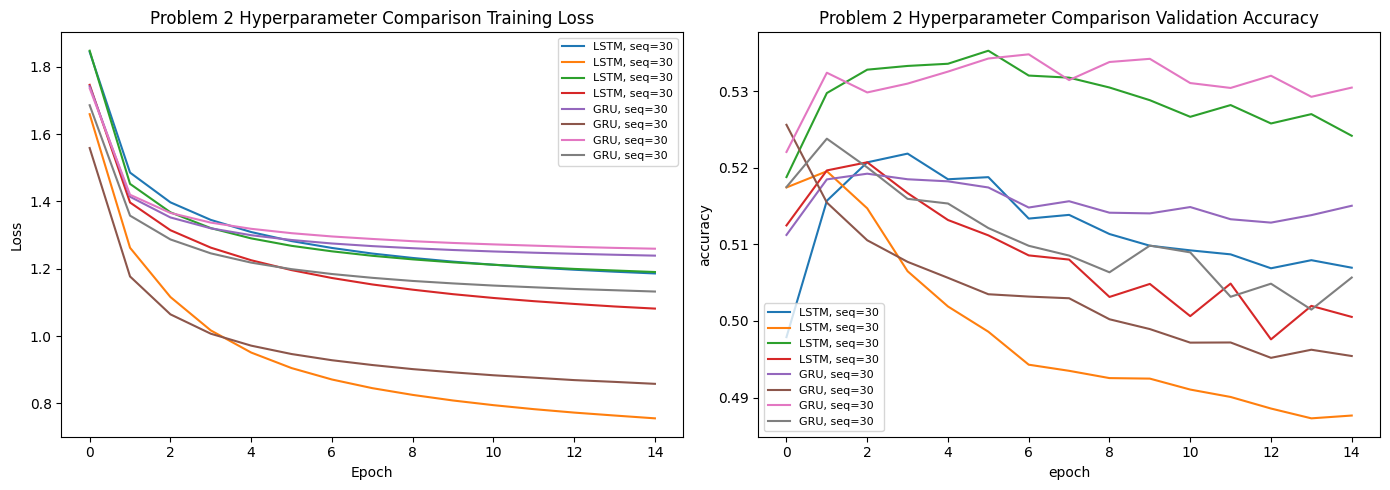

In [29]:
plot_histories(hyperparameter_results, "Problem 2 Hyperparameter Comparison")

In [30]:
problem1_df.to_csv("problem1_results.csv", index=False)
problem2_df.to_csv("problem2_sequence_results.csv", index=False)
hyperparameter_df.to_csv("problem2_hyperparameter_results.csv", index=False)

print("Saved:")
print("problem1_results.csv")
print("problem2_sequence_results.csv")
print("problem2_hyperparameter_results.csv")

Saved:
problem1_results.csv
problem2_sequence_results.csv
problem2_hyperparameter_results.csv
